In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/sloan-digital-sky-survey/Skyserver_SQL2_27_2018 6_51_39 PM.csv


In [2]:
import seaborn as sns 
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('/kaggle/input/sloan-digital-sky-survey/Skyserver_SQL2_27_2018 6_51_39 PM.csv')
df.head()

,objid,ra,dec,u,g,r,i,z,run,rerun,camcol,field,specobjid,class,redshift,plate,mjd,fiberid
0,1.237650e+18,183.531326,0.089693,19.47406,17.04240,15.94699,15.50342,15.22531,752,301,4,267,3.722360e+18,STAR,-0.000009,3306,54922,491
1,1.237650e+18,183.598370,0.135285,18.66280,17.21449,16.67637,16.48922,16.39150,752,301,4,267,3.638140e+17,STAR,-0.000055,323,51615,541
2,1.237650e+18,183.680207,0.126185,19.38298,18.19169,17.47428,17.08732,16.80125,752,301,4,268,3.232740e+17,GALAXY,0.123111,287,52023,513
3,1.237650e+18,183.870529,0.049911,17.76536,16.60272,16.16116,15.98233,15.90438,752,301,4,269,3.722370e+18,STAR,-0.000111,3306,54922,510
4,1.237650e+18,183.883288,0.102557,17.55025,16.26342,16.43869,16.55492,16.61326,752,301,4,269,3.722370e+18,STAR,0.000590,3306,54922,512


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   objid      10000 non-null  float64
 1   ra         10000 non-null  float64
 2   dec        10000 non-null  float64
 3   u          10000 non-null  float64
 4   g          10000 non-null  float64
 5   r          10000 non-null  float64
 6   i          10000 non-null  float64
 7   z          10000 non-null  float64
 8   run        10000 non-null  int64  
 9   rerun      10000 non-null  int64  
 10  camcol     10000 non-null  int64  
 11  field      10000 non-null  int64  
 12  specobjid  10000 non-null  float64
 13  class      10000 non-null  object 
 14  redshift   10000 non-null  float64
 15  plate      10000 non-null  int64  
 16  mjd        10000 non-null  int64  
 17  fiberid    10000 non-null  int64  
dtypes: float64(10), int64(7), object(1)
memory usage: 1.4+ MB


In [5]:
pd.set_option('display.float_format' , '{:.3f}'.format)

In [6]:
df.head()

,objid,ra,dec,u,g,r,i,z,run,rerun,camcol,field,specobjid,class,redshift,plate,mjd,fiberid
0,1237650000000000000.000,183.531,0.090,19.474,17.042,15.947,15.503,15.225,752,301,4,267,3722360000000000000.000,STAR,-0.000,3306,54922,491
1,1237650000000000000.000,183.598,0.135,18.663,17.214,16.676,16.489,16.392,752,301,4,267,363814000000000000.000,STAR,-0.000,323,51615,541
2,1237650000000000000.000,183.680,0.126,19.383,18.192,17.474,17.087,16.801,752,301,4,268,323274000000000000.000,GALAXY,0.123,287,52023,513
3,1237650000000000000.000,183.871,0.050,17.765,16.603,16.161,15.982,15.904,752,301,4,269,3722370000000000000.000,STAR,-0.000,3306,54922,510
4,1237650000000000000.000,183.883,0.103,17.550,16.263,16.439,16.555,16.613,752,301,4,269,3722370000000000000.000,STAR,0.001,3306,54922,512


In [7]:
col_to_drop = ['objid' , 'run' ,'rerun' , 'camcol' , 'field' , 'specobjid']
df.drop(columns = col_to_drop , axis = 1 , inplace = True)
df.head()

,ra,dec,u,g,r,i,z,class,redshift,plate,mjd,fiberid
0,183.531,0.090,19.474,17.042,15.947,15.503,15.225,STAR,-0.000,3306,54922,491
1,183.598,0.135,18.663,17.214,16.676,16.489,16.392,STAR,-0.000,323,51615,541
2,183.680,0.126,19.383,18.192,17.474,17.087,16.801,GALAXY,0.123,287,52023,513
3,183.871,0.050,17.765,16.603,16.161,15.982,15.904,STAR,-0.000,3306,54922,510
4,183.883,0.103,17.550,16.263,16.439,16.555,16.613,STAR,0.001,3306,54922,512


In [8]:
df['u-g'] = df['u'] - df['g']
df['g-r'] = df['g'] - df['r']
df['r-i'] = df['r'] - df['i']
df['i-z'] = df['i'] - df['z']
df.drop(columns = ['u' , 'g' , 'r' , 'i' , 'z'] , inplace = True)
df.head()

,ra,dec,class,redshift,plate,mjd,fiberid,u-g,g-r,r-i,i-z
0,183.531,0.090,STAR,-0.000,3306,54922,491,2.432,1.095,0.444,0.278
1,183.598,0.135,STAR,-0.000,323,51615,541,1.448,0.538,0.187,0.098
2,183.680,0.126,GALAXY,0.123,287,52023,513,1.191,0.717,0.387,0.286
3,183.871,0.050,STAR,-0.000,3306,54922,510,1.163,0.442,0.179,0.078
4,183.883,0.103,STAR,0.001,3306,54922,512,1.287,-0.175,-0.116,-0.058


In [9]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df['class'] = encoder.fit_transform(df['class'])
df.head()

,ra,dec,class,redshift,plate,mjd,fiberid,u-g,g-r,r-i,i-z
0,183.531,0.090,2,-0.000,3306,54922,491,2.432,1.095,0.444,0.278
1,183.598,0.135,2,-0.000,323,51615,541,1.448,0.538,0.187,0.098
2,183.680,0.126,0,0.123,287,52023,513,1.191,0.717,0.387,0.286
3,183.871,0.050,2,-0.000,3306,54922,510,1.163,0.442,0.179,0.078
4,183.883,0.103,2,0.001,3306,54922,512,1.287,-0.175,-0.116,-0.058


In [10]:
# EDA

<Figure size 1500x1000 with 0 Axes>

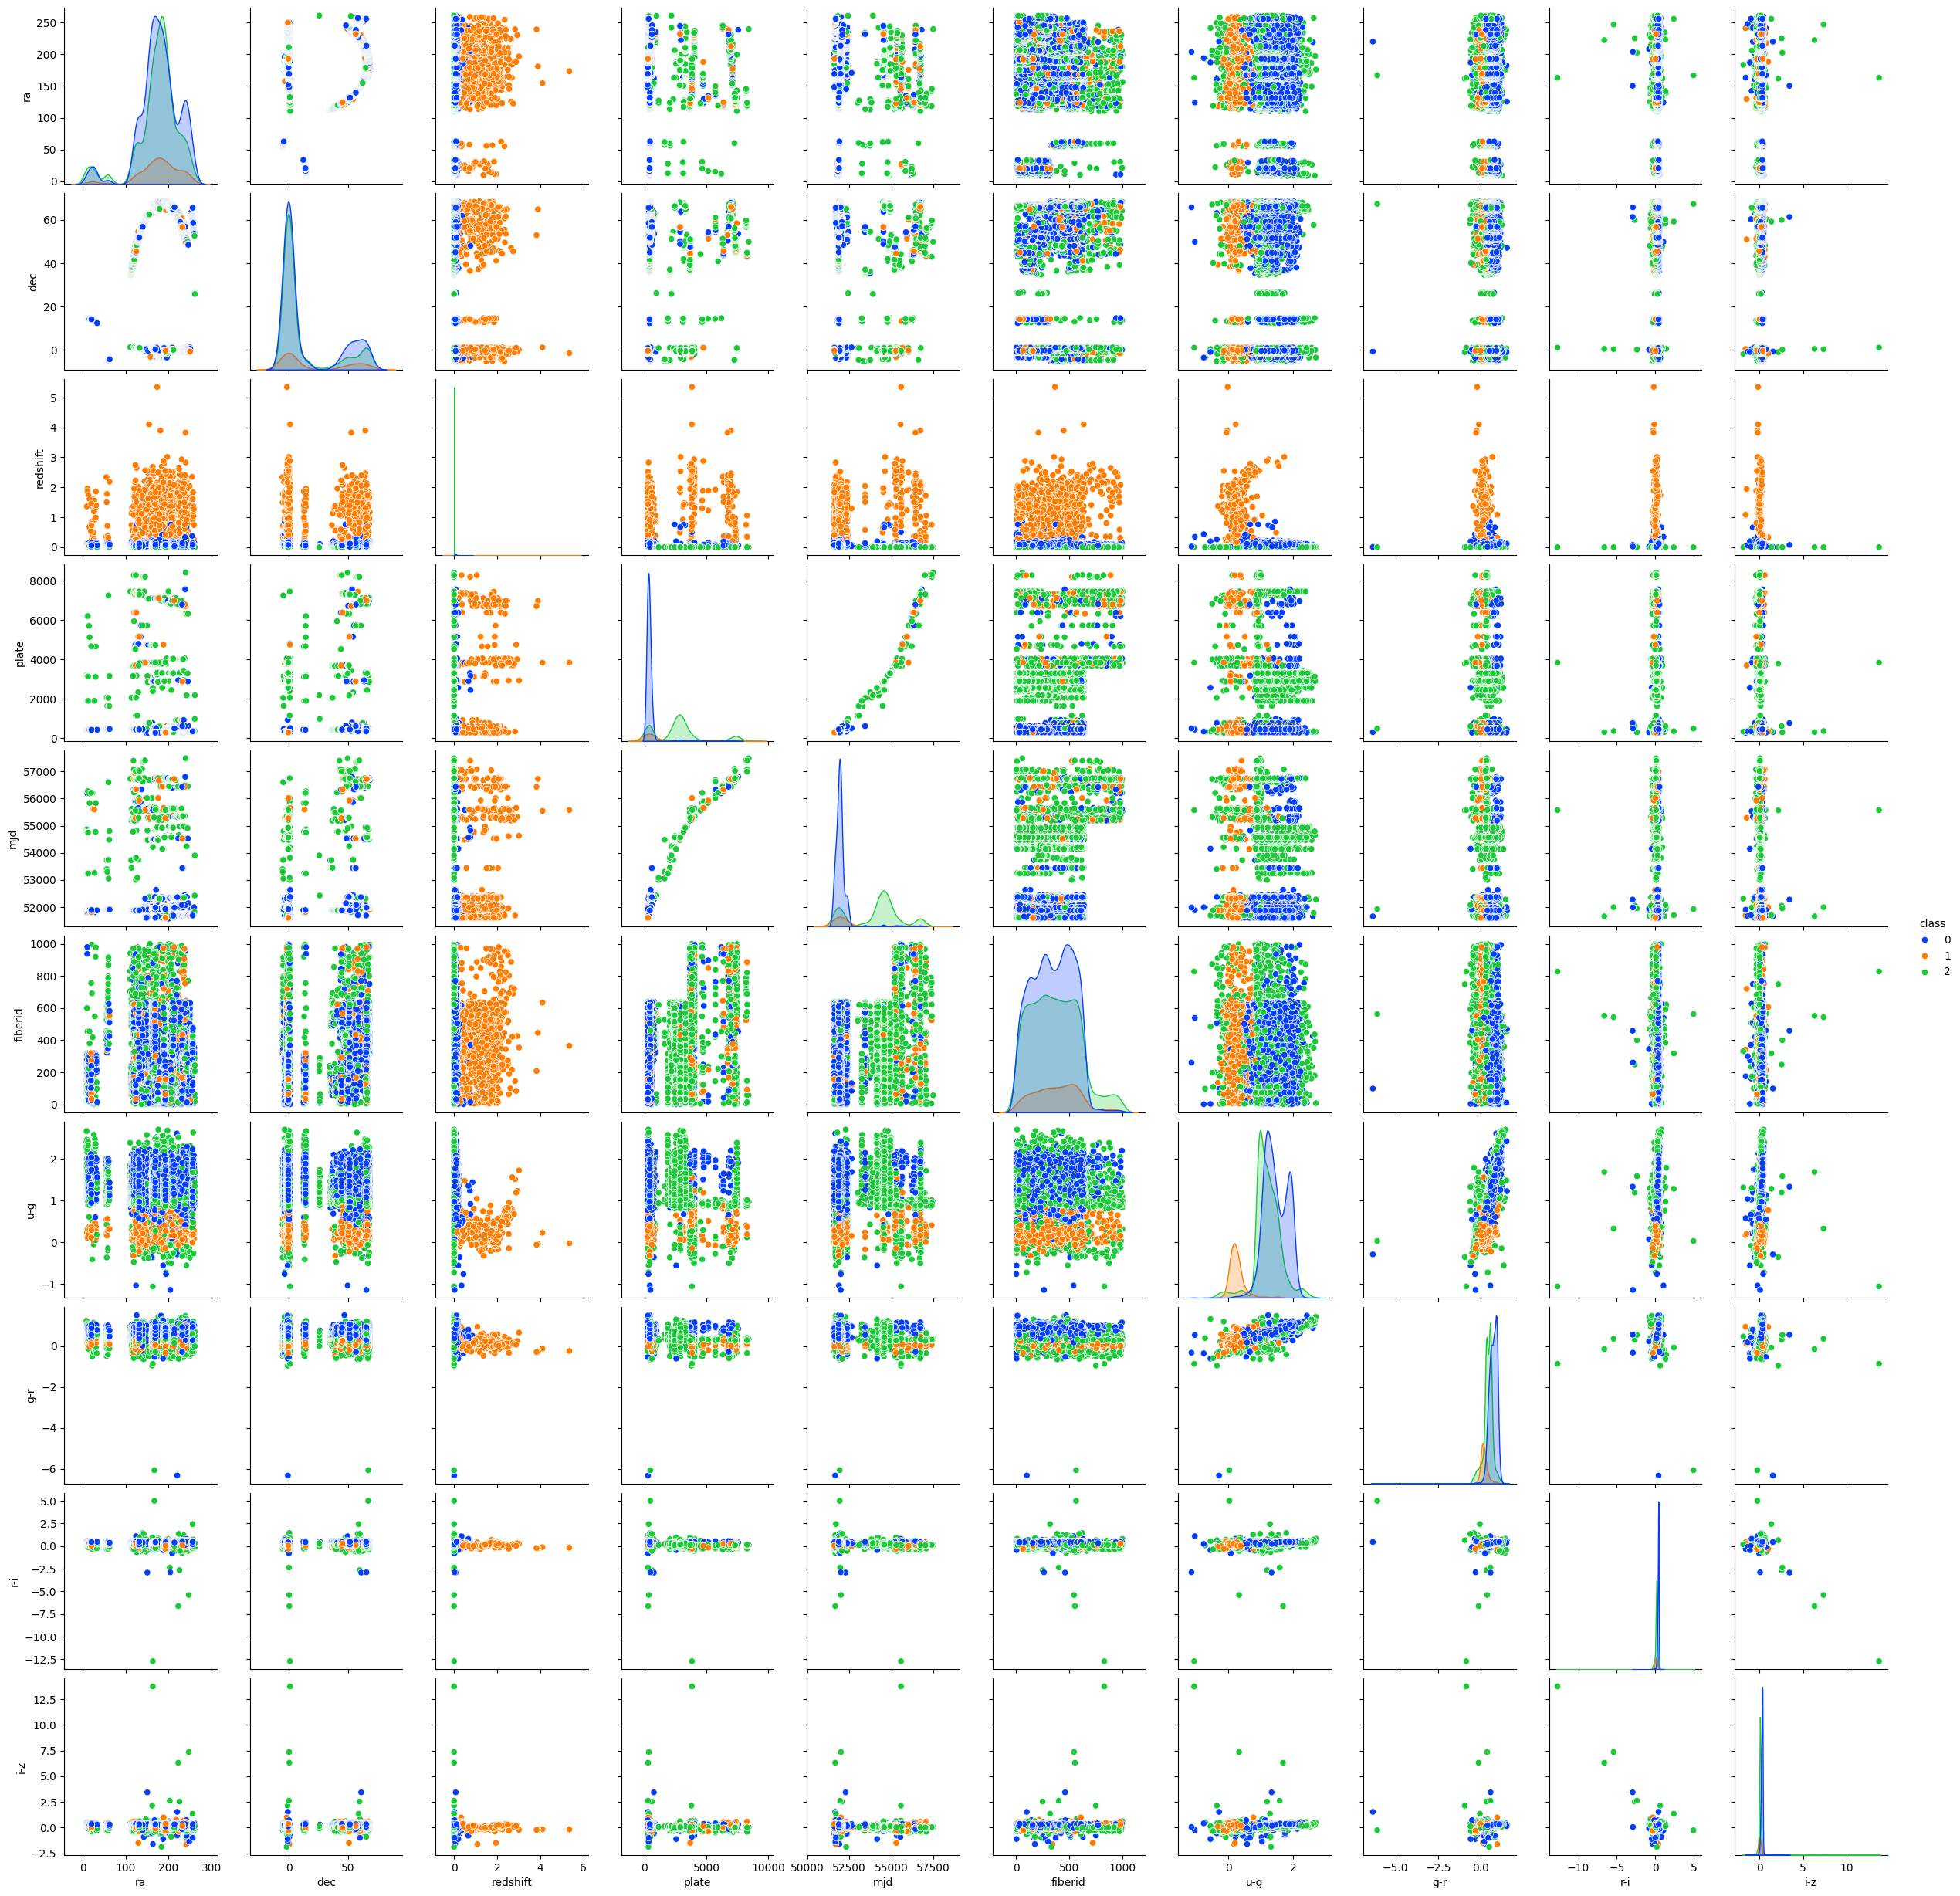

In [11]:
import warnings
warnings.filterwarnings('ignore')
plt.figure(figsize = (15 , 10))
sns.pairplot(df , hue = 'class' ,palette = 'bright')
plt.show()

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   ra        10000 non-null  float64
 1   dec       10000 non-null  float64
 2   class     10000 non-null  int64  
 3   redshift  10000 non-null  float64
 4   plate     10000 non-null  int64  
 5   mjd       10000 non-null  int64  
 6   fiberid   10000 non-null  int64  
 7   u-g       10000 non-null  float64
 8   g-r       10000 non-null  float64
 9   r-i       10000 non-null  float64
 10  i-z       10000 non-null  float64
dtypes: float64(7), int64(4)
memory usage: 859.5 KB


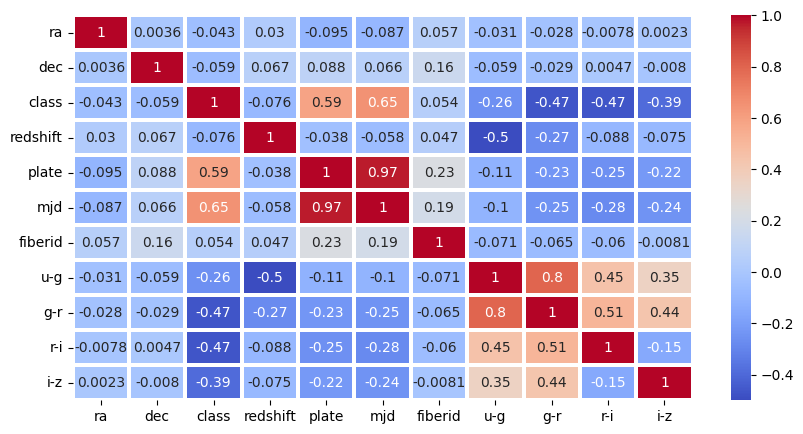

In [13]:
plt.figure(figsize = (10 , 5))
sns.heatmap(df.corr() , annot = True , linewidth = 1.6 , cmap = 'coolwarm')
plt.show()

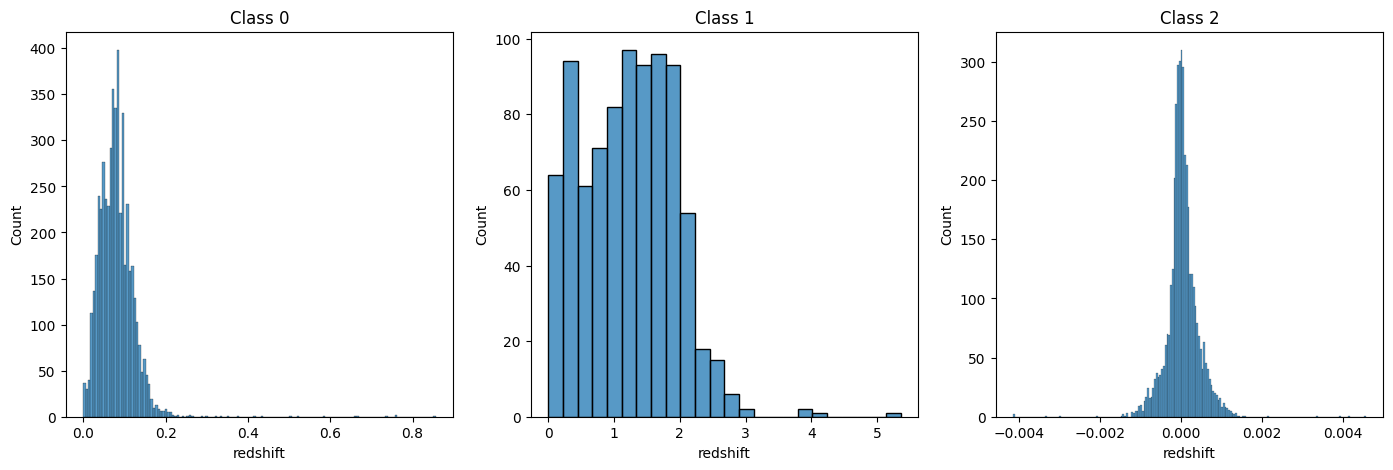

In [14]:
fig , axes = plt.subplots(nrows = 1 , ncols = 3 , figsize = (17 , 5))
ax = sns.histplot(df[df['class'] == 0].redshift , ax = axes[0])
ax.set_title('Class 0')
ax = sns.histplot(df[df['class'] == 1].redshift , ax = axes[1])
ax.set_title('Class 1')
ax = sns.histplot(df[df['class'] == 2].redshift , ax = axes[2])
ax.set_title('Class 2')
plt.show()

In [15]:
!pip install xgboost

In [16]:
X = df.drop(columns = 'class' , axis = 1)
y = df['class']

from sklearn.model_selection import train_test_split 

X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.3 , random_state = 15)


In [17]:
from xgboost import XGBClassifier
xgbc = XGBClassifier()

In [18]:
xgbc.fit(X_train , y_train)
y_pred = xgbc.predict(X_test)

from sklearn.metrics import accuracy_score , confusion_matrix , classification_report

print('ACCURACY : ' , accuracy_score(y_test , y_pred))
print('CLASSIFICATIPN REPORT \n: ' , classification_report(y_test , y_pred))
print('CONFUSION MATRIX : \n' , confusion_matrix(y_test , y_pred))

ACCURACY :  0.989
CLASSIFICATIPN REPORT 
:                precision    recall  f1-score   support

           0       0.99      0.99      0.99      1532
           1       0.98      0.94      0.96       247
           2       0.99      1.00      0.99      1221

    accuracy                           0.99      3000
   macro avg       0.99      0.98      0.98      3000
weighted avg       0.99      0.99      0.99      3000

CONFUSION MATRIX : 
 [[1520    5    7]
 [  14  232    1]
 [   6    0 1215]]


In [19]:
# Hyperparamether Tuning

In [20]:
params = {
    'n_estimators' : [100 , 200 , 300 , 400],
    'max_depth' : [6 , 8 , 10, 13 ,15 ,20],
    'gamma': [0.001, 0.01, 0.1, 1.0], 
    'min_child_weight': [1, 3, 5, 10],
    'subsample': [0.5, 0.7, 0.9, 1.0],
    'learning_rate' : [0.01 , 0.1 , 0.5]
} 

In [21]:
from sklearn.model_selection import RandomizedSearchCV
random = RandomizedSearchCV(estimator = XGBClassifier() , param_distributions = params , scoring = 'accuracy' , n_jobs = -1 , cv = 5)

In [22]:
random.fit(X_train , y_train)
y_pred = random.predict(X_test)

print('ACCURACY : ' , accuracy_score(y_test , y_pred))
print('CLASSIFICATIPN REPORT \n: ' , classification_report(y_test , y_pred))
print('CONFUSION MATRIX : \n' , confusion_matrix(y_test , y_pred))

ACCURACY :  0.9903333333333333
CLASSIFICATIPN REPORT 
:                precision    recall  f1-score   support

           0       0.99      0.99      0.99      1532
           1       0.97      0.94      0.96       247
           2       0.99      1.00      1.00      1221

    accuracy                           0.99      3000
   macro avg       0.99      0.98      0.98      3000
weighted avg       0.99      0.99      0.99      3000

CONFUSION MATRIX : 
 [[1520    6    6]
 [  13  233    1]
 [   3    0 1218]]
